# Clasificación de sentimiento de reseñas — Parte 1 (ML clásico)

Aprendizaje de Máquina 2026-20, Universidad de los Andes.

**Objetivo:** clasificar reseñas de productos en español en `negativo`, `neutral` o `positivo` usando únicamente
modelos de scikit-learn y representaciones clásicas de texto (bag-of-words, TF-IDF, n-gramas).

**Modelo final de este notebook:** experimento 13 — Dos niveles: nivel 1 sin reseñas ruidosas + combinador lineal con interacciones.

Este notebook reúne todo el proceso: la exploración de los datos, el preprocesamiento, el esquema de validación, la
evolución de los 14 experimentos realizados (con sus decisiones y descartes) y la implementación, el entrenamiento y
la evaluación completos del modelo final. Cada experimento tiene además su propio notebook en el repositorio
(`experimentoN.ipynb`) con todo el detalle; aquí se resumen sus resultados como valores fijos.

**Contenido**
0. Configuración y carga de datos
1. Exploración de los datos
2. Preprocesamiento
3. Esquema de validación
4. Evolución de los experimentos
5. Modelo final
6. Sobreajuste y robustez
7. Envío y modelo guardado
8. Conclusiones
9. Uso de IA generativa

## 0. Configuración y carga de datos

### 0.1 Librerías y semilla

In [1]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

# Semilla fija para que todos los resultados sean replicables
SEED = 42
np.random.seed(SEED)

# Orden y color fijo de las clases en todo el notebook
CLASES = ["negativo", "neutral", "positivo"]
COLORES = {"negativo": "#2a78d6", "neutral": "#eb6834", "positivo": "#1baf7a"}

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

# Los datos y la carpeta envios/ están en la raíz del proyecto (este notebook está en entrega/)
import os

if not Path("train.csv").exists() and Path("../train.csv").exists():
    os.chdir("..")
print("Directorio de trabajo:", Path.cwd())

Directorio de trabajo: C:\Users\jpard\talleres_ml\project_ml_p1


### 0.2 Carga de datos

Se cargan los archivos originales y se trabaja sobre copias (`.copy()`) para no modificar los datos crudos.
`eval.csv` **no tiene etiqueta**: solo se usa para generar las predicciones que se envían a Kaggle, nunca para entrenar.

In [2]:
train_raw = pd.read_csv("train.csv")
eval_raw = pd.read_csv("eval.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train = train_raw.copy()
eval_df = eval_raw.copy()

print("train:", train.shape)
print("eval:", eval_df.shape)
print("sample_submission:", sample_submission.shape)

train: (12000, 3)
eval: (3000, 2)
sample_submission: (3000, 2)


In [3]:
train.head()

,id,text,label
0,0,"Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kilo. Lo tengo en el es...",neutral
1,1,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban ...",positivo
2,2,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día....",negativo
3,3,"Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por una. El ensamblaje terminó siendo impreciso para lo que necesitaba, la verdad. ...",negativo
4,4,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los ...",positivo


In [4]:
eval_df.head()

,id,text
0,0,"Hice el pedido desde la aplicacion un martes por la tarde y llego a mi casa al dia siguiente. El paquete venia bien cerrado y, de paquete, traia ademas una bolsa de tela. Esa bolsa la estoy usando..."
1,1,"Compre esto a principios de mes porque andaba necesitando uno, llego en unos cuantos dias a mi casa. Al principio el rendimiento me parecio flojo tras el primer mes, la verdad le tenia fe pero ahi..."
2,2,"Lo pedí un martes y me llegó el jueves a la casa. Lo compré para reemplazar uno anterior que ya tenía en el cuarto de baño. Viene en cuatro tamaños distintos, así que alcanza para varias personas...."
3,3,"Me llegó el miércoles pasado, tres días después de hacer el pedido. Lo pruebo casi a diario desde hace poco, nomás lo saco un rato en las tardes. Mide como veinte centímetros y cabe sin problema e..."
4,4,"Lo pedí un martes y llegó el jueves a la casa. En el paquete venían dos unidades, tal cual. Las medidas coinciden con lo que dice la descripción. Las medí con una cinta métrica apenas las recibí p..."


In [5]:
sample_submission.head()

,id,answer
0,0,neutral
1,1,neutral
2,2,neutral
3,3,neutral
4,4,neutral


## 1. Exploración de los datos

Antes de modelar se revisa: la estructura y calidad básica, la distribución de clases, la longitud de los textos,
la presencia de conectores contrastivos y negaciones (el núcleo de la dificultad del problema), ejemplos reales,
el ruido del texto y los n-gramas más frecuentes por clase.

### 1.1 Estructura y calidad básica

In [6]:
calidad = pd.DataFrame({
    "chequeo": [
        "Nulos en train",
        "Nulos en eval",
        "ids repetidos en train",
        "Textos duplicados en train",
        "Textos de eval que también están en train",
        "ids de eval iguales a los de sample_submission",
    ],
    "resultado": [
        int(train.isna().sum().sum()),
        int(eval_df.isna().sum().sum()),
        int(train["id"].duplicated().sum()),
        int(train["text"].duplicated().sum()),
        int(eval_df["text"].isin(train["text"]).sum()),
        bool(set(eval_df["id"]) == set(sample_submission["id"])),
    ],
})
calidad

,chequeo,resultado
0,Nulos en train,0
1,Nulos en eval,0
2,ids repetidos en train,0
3,Textos duplicados en train,0
4,Textos de eval que también están en train,0
5,ids de eval iguales a los de sample_submission,True


### 1.2 Distribución de clases

,reseñas,%
label,,
negativo,4212,35.1
neutral,3576,29.8
positivo,4212,35.1


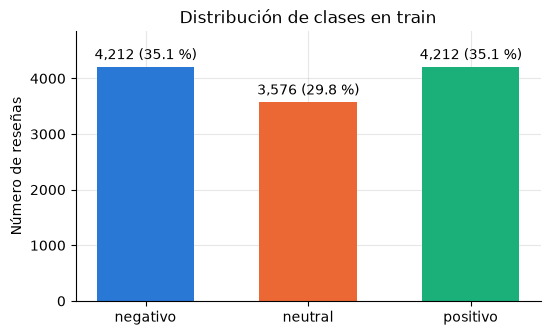

Accuracy de predecir siempre la clase mayoritaria: 0.351


In [7]:
conteo = train["label"].value_counts().reindex(CLASES)
porcentaje = (conteo / conteo.sum() * 100).round(1)
display(pd.DataFrame({"reseñas": conteo, "%": porcentaje}))

fig, ax = plt.subplots(figsize=(6, 3.5))
barras = ax.bar(CLASES, conteo.values, color=[COLORES[c] for c in CLASES], width=0.6)
ax.bar_label(barras, labels=[f"{n:,} ({p} %)" for n, p in zip(conteo.values, porcentaje.values)], padding=3)
ax.set_ylabel("Número de reseñas")
ax.set_title("Distribución de clases en train")
ax.set_ylim(0, conteo.max() * 1.15)
plt.show()

print(f"Accuracy de predecir siempre la clase mayoritaria: {conteo.max() / conteo.sum():.3f}")

### 1.3 Longitud de las reseñas

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


eval, palabras por reseña:


,count,mean,std,min,25%,50%,75%,max
n_palabras,3000.0,54.2,13.1,4.0,48.0,54.0,61.0,104.0


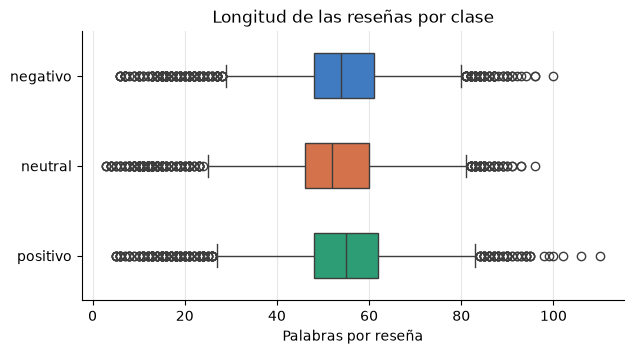

In [8]:
train["n_palabras"] = train["text"].str.split().str.len()
train["n_caracteres"] = train["text"].str.len()
eval_df["n_palabras"] = eval_df["text"].str.split().str.len()

display(train.groupby("label")["n_palabras"].describe().reindex(CLASES).round(1))
print("eval, palabras por reseña:")
display(eval_df["n_palabras"].describe().round(1).to_frame().T)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.boxplot(data=train, x="n_palabras", y="label", hue="label", order=CLASES,
            palette=COLORES, legend=False, width=0.5, ax=ax)
ax.set_xlabel("Palabras por reseña")
ax.set_ylabel("")
ax.set_title("Longitud de las reseñas por clase")
plt.show()

### 1.4 Conectores contrastivos y negación

El enunciado advierte que el sentimiento global depende del orden, la negación y los conectores contrastivos.
Se mide en qué porcentaje de reseñas de cada clase aparece cada marcador (búsqueda sin distinguir mayúsculas ni tildes).

In [9]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
texto_basico = train["text"].str.lower().str.translate(TILDES)

MARCADORES = {
    "pero": r"\bpero\b",
    "aunque": r"\baunque\b",
    "sin embargo": r"\bsin embargo\b",
    "aun asi": r"\baun asi\b",
    "en cambio": r"\ben cambio\b",
    "por otro lado": r"\bpor otro lado\b",
    "al final": r"\bal final\b",
    "en fin": r"\ben fin\b",
    "la verdad": r"\bla verdad\b",
    "no": r"\bno\b",
    "ni": r"\bni\b",
    "nada": r"\bnada\b",
    "nunca": r"\bnunca\b",
    "sin": r"\bsin\b",
}

presencia = pd.DataFrame({m: texto_basico.str.contains(p, regex=True) for m, p in MARCADORES.items()})
pct_marcadores = (presencia.groupby(train["label"]).mean().T[CLASES] * 100).round(1)
pct_marcadores["total"] = (presencia.mean() * 100).round(1)
pct_marcadores

label,negativo,neutral,positivo,total
pero,9.5,3.7,3.8,5.8
aunque,4.9,2.7,3.9,3.9
sin embargo,1.5,0.0,1.4,1.0
aun asi,7.4,0.0,10.4,6.3
en cambio,0.3,0.0,0.5,0.3
por otro lado,7.3,3.6,7.2,6.1
al final,13.9,0.7,13.7,9.9
en fin,1.4,0.1,1.5,1.0
la verdad,36.3,2.3,38.7,27.0
no,27.1,40.6,25.9,30.7


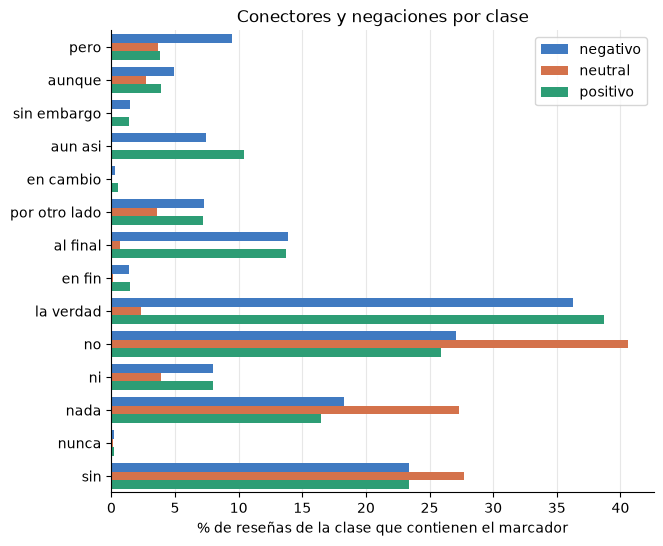

In [10]:
largo = pct_marcadores[CLASES].reset_index(names="marcador").melt(
    id_vars="marcador", var_name="clase", value_name="pct")

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(data=largo, y="marcador", x="pct", hue="clase", hue_order=CLASES,
            palette=COLORES, orient="h", ax=ax)
ax.set_xlabel("% de reseñas de la clase que contienen el marcador")
ax.set_ylabel("")
ax.set_title("Conectores y negaciones por clase")
ax.legend(title="")
plt.show()

### 1.5 Ejemplos por clase

In [11]:
for clase in CLASES:
    print(f"==================== {clase.upper()} ====================")
    for texto in train.loc[train["label"] == clase, "text"].sample(2, random_state=SEED):
        print(texto, "\n")

==================== NEGATIVO ====================
La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó. 

Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora. 

==================== NEUTRAL ====================
Lo pedí un martes por la tarde porque justo andaba cerca de la oficina donde lo iba a usar. Llegó en menos de tres días, o sea que el jueves ya lo tenía en casa. Lo entregó la mensajería de siempre, el mismo señor que suele pasar por la cuadra, y me lo dejó en la recepción porque no estaba. La caja venía cerrada con su plástico. Trae garantía de seis meses según el papel

### 1.6 Ruido en el texto

Se buscan de forma automática (con conteos y expresiones regulares sobre todas las filas) problemas de codificación,
tildes inconsistentes, errores de tipeo y otros patrones que la normalización debe tratar.

In [12]:
def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón (admite grupos de captura)."""
    return serie.map(lambda t: re.search(patron, t) is not None)


PATRONES_RUIDO = {
    "mojibake (Ã)": r"Ã",
    "tildes graves (à è ì ò ù)": r"[àèìòù]",
    "letra repetida 3+ veces": r"([a-záéíóúñ])\1\1",
    "palabra en MAYÚSCULAS (3+ letras)": r"\b[A-ZÁÉÍÓÚÑ]{3,}\b",
    "contiene dígitos": r"\d",
}

ruido = pd.DataFrame({
    "train": {n: int(contiene(train["text"], p).sum()) for n, p in PATRONES_RUIDO.items()},
    "eval": {n: int(contiene(eval_df["text"], p).sum()) for n, p in PATRONES_RUIDO.items()},
})
ruido

,train,eval
mojibake (Ã),2,0
tildes graves (à è ì ò ù),1,0
letra repetida 3+ veces,8,0
palabra en MAYÚSCULAS (3+ letras),743,182
contiene dígitos,1126,241


In [13]:
def mostrar_contexto(patron, n=2, ancho=70):
    """Imprime el fragmento alrededor de la primera coincidencia en n reseñas."""
    filas = train[contiene(train["text"], patron)].head(n)
    for _, fila in filas.iterrows():
        m = re.search(patron, fila["text"])
        ini, fin = max(0, m.start() - ancho), m.end() + ancho
        print(f"  [{fila['label']}] ...{fila['text'][ini:fin]}...")

for nombre, patron in PATRONES_RUIDO.items():
    print(nombre)
    mostrar_contexto(patron)
    print()

mojibake (Ã)
  [neutral] ...Pues aquÃ­ va lo prometido, mi reseÃ±a del artÃ­culo. Me llegÃ³ el martes por l...
  [neutral] ...Hace poco lo comprÃ© por internet para reemplazar otro que tenÃ­a en casa desde hacÃ­a aÃ...

tildes graves (à è ì ò ù)
  [neutral] ...Pues aquì va mi reseña. El paquete llegò en cuatro dìas y lo trajo la mensajerì...

letra repetida 3+ veces
  [positivo] ... dias. Me encanto la portabilidad de principio a fin. Por cierto, me arrrepiento de haber elegido la atencion al cliente. Ni tan bueno ni tan m...
  [negativo] ... para el trabajo diario. La instalacion me costo, le pondria una estrellla a esa parte. La memoria en cambio quedo encantada, la verdad muy con...

palabra en MAYÚSCULAS (3+ letras)
  [negativo] ...a. La carga es por un conector magnético en un puerto propio, nada de USB normal. Me decepcionó la construcción de principio a fin, la verdad. ...
  [neutral] ...ondo, le di varios usos seguidos para ver como venia. Carga por micro USB, o sea que hay que

In [14]:
# Vocabulario: palabras escritas de varias formas (con/sin tilde) y palabras que aparecen una sola vez
frecuencias = Counter(t for texto in train["text"].str.lower() for t in re.findall(r"\w+", texto))

variantes = {}
for palabra in frecuencias:
    variantes.setdefault(palabra.translate(TILDES), set()).add(palabra)
grupos_tilde = [sorted(v) for v in variantes.values() if len(v) > 1]

hapax = [p for p, f in frecuencias.items() if f == 1]

print(f"Palabras distintas (en minúscula): {len(frecuencias):,}")
print(f"Palabras con varias escrituras por tildes: {len(grupos_tilde):,} grupos, p. ej. {grupos_tilde[:6]}")
print(f"Palabras que aparecen una sola vez (hapax): {len(hapax):,} ({len(hapax) / len(frecuencias):.0%} del vocabulario)")
print("Ejemplos de hapax:", hapax[:30])

Palabras distintas (en minúscula): 6,054
Palabras con varias escrituras por tildes: 507 grupos, p. ej. [['pedi', 'pedí'], ['llego', 'llegò', 'llegó'], ['dia', 'día'], ['el', 'él'], ['basico', 'básico'], ['linea', 'línea']]
Palabras que aparecen una sola vez (hapax): 2,416 (40% del vocabulario)
Ejemplos de hapax: ['pensarla', 'tardaban', 'ríen', 'desordenado', 'gestión', 'acabarla', 'amolar', 'teenr', 'arrrepiento', 'receptor', 'armábamos', 'meediano', 'windows', 'contestan', 'reelacion', 'sostuve', 'coomprar', 'exhibicion', 'confirmarlo', 'pan', 'reppisa', 'conuslto', 'remisión', 'entendía', 'familiarizarme', 'entienden', 'crema', 'fabriante', 'toods', 'usuario']


In [15]:
# ¿El ruido está asociado a alguna clase? (posible pista falsa para el modelo)
asociacion = pd.DataFrame({
    n: train.loc[contiene(train["text"], p), "label"].value_counts().reindex(CLASES, fill_value=0)
    for n, p in PATRONES_RUIDO.items()
}).T
asociacion

label,negativo,neutral,positivo
mojibake (Ã),0,2,0
tildes graves (à è ì ò ù),0,1,0
letra repetida 3+ veces,2,0,6
palabra en MAYÚSCULAS (3+ letras),133,455,155
contiene dígitos,203,722,201


In [16]:
# Las palabras en mayúscula, ¿qué son?
mayusculas = Counter(m for texto in train["text"] for m in re.findall(r"\b[A-ZÁÉÍÓÚÑ]{3,}\b", texto))
mayusculas.most_common(15)

[('USB', 548),
 ('AAA', 178),
 ('HDMI', 19),
 ('RAM', 8),
 ('USBC', 3),
 ('GPS', 1),
 ('CPU', 1),
 ('CDMX', 1),
 ('AAAA', 1),
 ('OXXO', 1)]

### 1.7 Bigramas más frecuentes por clase

Si los bigramas más frecuentes son casi los mismos en las tres clases, significa que gran parte del texto es relleno
compartido (compra, envío, uso) que no ayuda a distinguir el sentimiento. Esto motiva usar TF-IDF, que reduce el peso
de los términos presentes en muchas reseñas.

In [17]:
def top_ngramas(textos, n=10, ngram=(2, 2)):
    vec = CountVectorizer(ngram_range=ngram)
    X = vec.fit_transform(textos)
    totales = np.asarray(X.sum(axis=0)).ravel()
    orden = totales.argsort()[::-1][:n]
    return [f"{vec.get_feature_names_out()[i]} ({totales[i]})" for i in orden]

pd.DataFrame({c: top_ngramas(texto_basico[train["label"] == c], n=12) for c in CLASES})

,negativo,neutral,positivo
0,llego en (2474),en la (2487),llego en (2441)
1,en la (1969),llego en (1707),en la (2007)
2,lo compre (1705),lo compre (1409),la verdad (1731)
3,la verdad (1608),en el (1401),lo compre (1533)
4,me llego (1396),me llego (1380),me llego (1501)
5,en el (1389),lo pedi (1249),en el (1411)
6,lo que (1342),la caja (1236),tres dias (1404)
7,tres dias (1329),de la (1086),lo uso (1342)
8,lo uso (1181),el paquete (1012),lo que (1202)
9,cuatro dias (1151),tres dias (920),en tres (1184)


### 1.8 Conclusiones de la exploración

1. **Datos limpios en estructura:** sin nulos, sin duplicados, sin textos compartidos entre train y eval, y los ids de
   eval coinciden con los de `sample_submission`.
2. **Clases casi balanceadas** (35,1 % / 29,8 % / 35,1 %). Predecir siempre la clase mayoritaria da 35,1 % de
   accuracy: es el piso mínimo. No se necesita `class_weight` de entrada.
3. **La longitud no distingue clases:** las tres tienen una mediana de 52 a 55 palabras, y eval tiene la misma distribución.
4. **Las reseñas `neutral` casi nunca usan conectores de juicio:** `aun así` (0 %), `al final` (0,7 %), `la verdad`
   (2,3 %) frente a 7–39 % en las otras clases. En cambio, tienen más dígitos y siglas (`USB`, `AAA`, `110 voltios`):
   son reseñas descriptivas. Separar `neutral` debería ser relativamente fácil.
5. **Entre `negativo` y `positivo` los conectores aparecen con la misma frecuencia** (`al final` 13,9 % vs 13,7 %,
   `aun así` 7,4 % vs 10,4 %). Su presencia no decide la clase; lo que decide es **qué dice la cláusula que viene
   después**. Ejemplo `positivo`: *"el rendimiento me resultó ser mal terminado [...] Sin embargo, el procesador se
   mantuvo espectacular"*. Esto confirma que el orden importa y motiva el experimento de la cláusula tras el conector.
6. **`no` y `nada` son más frecuentes en `neutral`** (40,6 % y 27,3 %) porque se usan de forma descriptiva
   (*"no hubo ningún problema"*, *"nada fuera de lo común"*). Por sí solas no indican sentimiento negativo: se
   necesitan bigramas.
7. **Los bigramas más frecuentes son casi los mismos en las tres clases** (`llego en`, `lo compre`, `tres dias`): una
   gran parte del texto es relleno sobre compra y envío. Esto justifica TF-IDF frente a conteos simples.
8. **Hay ruido inyectado que la normalización debe tratar:**
   - 507 palabras aparecen con y sin tilde (`llego` / `llegó` / `llegò`);
   - el 40 % del vocabulario son palabras que aparecen una sola vez, muchas de ellas errores de tipeo (`coomprar`,
     `conuslto`, `toods`);
   - hay letras repetidas (`errror`) y mojibake (`aquÃ­`) en unas pocas filas.
   Los errores de tipeo motivan probar n-gramas de caracteres y corrección por distancia de edición.
9. **Hay algo de ironía:** p. ej. *"la interfaz fue 'todo un acierto', como dicen, puro problema"*. Es difícil para
   cualquier bolsa de palabras, y se espera que aparezca en el análisis de errores.

## 2. Preprocesamiento

**Principio:** se define una única función `normalizar_texto()` que se aplica **igual en todos los experimentos**,
tanto a train como a eval. Es determinística (transforma cada texto por separado, sin aprender nada de los datos),
por lo que puede aplicarse antes de separar train/validación sin fuga de información. Lo que sí se aprende de los
datos (vocabulario, IDF) queda dentro del `Pipeline` de cada experimento.

| Paso | Qué hace | Por qué |
|---|---|---|
| 1. Reparar mojibake | `aquÃ­` → `aquí` | tildes mal codificadas partirían una palabra en tokens basura |
| 2. Minúsculas | `USB` → `usb` | la mayúscula no aporta sentimiento (son siglas) |
| 3. Quitar tildes (conservando la ñ) | `llegó` / `llegò` → `llego` | cientos de palabras aparecen con y sin tilde; unificarlas concentra la evidencia |
| 4. Letras repetidas 3+ → 2 | `errror` → `error` | corrige tipeos; se deja en 2 porque el español tiene `rr`, `ll`, `ee` legítimos |
| 5. Espacios | colapsa espacios múltiples | limpieza |

**Qué no se hace y por qué**
- **No se quitan stopwords:** las listas en español incluyen `no`, `pero`, `aunque`, `nada`, `sin`, `muy`, que son
  justamente las palabras que definen el sentimiento en este problema; además romperían bigramas como `no funciona`.
  TF-IDF y la regularización ya reducen el peso de las palabras frecuentes sin información.
- **No se quita la puntuación aquí:** el tokenizador del vectorizador la ignora al contar palabras, pero se conserva
  para poder separar la reseña en oraciones y cláusulas.
- **No se usa lematización con spaCy ni embeddings:** los modelos de spaCy y los embeddings preentrenados son redes
  neuronales, prohibidas en la Parte 1.

**Pasos adicionales que dependen del modelo** (se probaron en los experimentos 2, 9 y 10): el modelo final aplica
una **corrección de tipeo por distancia de edición** (sección 5.2) que aprende su vocabulario de los datos de
entrenamiento, por lo que va dentro del modelo y no aquí. El stemming no mejoró la accuracy (experimento 10) y el
reemplazo de números tampoco; no se usan.

In [18]:
# TILDES (definido en 1.4) quita tildes agudas, graves, diéresis y circunflejos; la ñ no se toca
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    """Repara caracteres UTF-8 leídos como Latin-1 (p. ej. 'Ã­' -> 'í')."""
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    """Normalización base aplicada a todas las reseñas en todos los experimentos."""
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


# Pruebas rápidas de la función
casos = {
    "Pues aquÃ­ va mi reseÃ±a": "pues aqui va mi reseña",
    "El paquete llegò en cuatro dìas": "el paquete llego en cuatro dias",
    "Fue un errror, le pondría una estrellla": "fue un error, le pondria una estrella",
    "Carga por USB-C, 110 voltios": "carga por usb-c, 110 voltios",
    "El año pasado  lo compré": "el año pasado lo compre",
}
for entrada, esperado in casos.items():
    salida = normalizar_texto(entrada)
    assert salida == esperado, (entrada, salida)
    print(f"{entrada:42} -> {salida}")

Pues aquÃ­ va mi reseÃ±a                   -> pues aqui va mi reseña
El paquete llegò en cuatro dìas            -> el paquete llego en cuatro dias
Fue un errror, le pondría una estrellla    -> fue un error, le pondria una estrella
Carga por USB-C, 110 voltios               -> carga por usb-c, 110 voltios
El año pasado  lo compré                   -> el año pasado lo compre


In [19]:
train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

# Antes y después en las reseñas con ruido
ruidosas = contiene(train["text"], r"Ã|[àèìòù]|([a-záéíóúñ])\1\1")
for _, fila in train[ruidosas].head(4).iterrows():
    print("ANTES  :", fila["text"][:160])
    print("DESPUÉS:", fila["text_norm"][:160], "\n")

ANTES  : Llevando un tiempo con el, lo pruebo casi todos los dias. Me encanto la portabilidad de principio a fin. Por cierto, me arrrepiento de haber elegido la atencion
DESPUÉS: llevando un tiempo con el, lo pruebo casi todos los dias. me encanto la portabilidad de principio a fin. por cierto, me arrepiento de haber elegido la atencion  

ANTES  : Pues aquÃ­ va lo prometido, mi reseÃ±a del artÃ­culo. Me llegÃ³ el martes por la tarde, unos tres dÃ­as despuÃ©s de la compra. El color es rojo, tal cual se veÃ
DESPUÉS: pues aqui va lo prometido, mi reseña del articulo. me llego el martes por la tarde, unos tres dias despues de la compra. el color es rojo, tal cual se veia en l 

ANTES  : Lo uso en la oficina desde hace un tiempo, me lo lleve para el trabajo diario. La instalacion me costo, le pondria una estrellla a esa parte. La memoria en camb
DESPUÉS: lo uso en la oficina desde hace un tiempo, me lo lleve para el trabajo diario. la instalacion me costo, le pondria una estrella a esa par

In [20]:
# Efecto sobre el vocabulario
vocab_antes = Counter(t for texto in train["text"].str.lower() for t in re.findall(r"\w+", texto))
vocab_despues = Counter(t for texto in train["text_norm"] for t in re.findall(r"\w+", texto))

pd.DataFrame({
    "palabras distintas": [len(vocab_antes), len(vocab_despues)],
    "hapax": [sum(f == 1 for f in vocab_antes.values()), sum(f == 1 for f in vocab_despues.values())],
}, index=["solo minúsculas", "normalizar_texto()"])

,palabras distintas,hapax
solo minúsculas,6054,2416
normalizar_texto(),5505,2213


## 3. Esquema de validación

`eval.csv` no tiene etiquetas: solo sirve para generar el envío a Kaggle. Toda la validación sale de `train.csv`:

```
train.csv (12.000 con etiqueta)
 ├── 80 % → 9.600  X_train: entrenamiento y validación cruzada (CV)
 └── 20 % → 2.400  X_test: test hold-out, nunca se usa para decidir, solo se reporta
eval.csv  (3.000 sin etiqueta) → solo predecir y enviar a Kaggle
```

| Regla | Detalle |
|---|---|
| Se decide con la CV | accuracy media de validación cruzada sobre `X_train`; el test solo confirma |
| CV repetida 3 × 5 | 15 particiones (`RepeatedStratifiedKFold`): las diferencias entre los mejores modelos son de décimas y con 5 folds quedarían dentro del ruido |
| Sin leakage | todo lo que aprende de los datos (vocabulario, IDF, detector de opinión, selección de features, filtro de reseñas ruidosas) va dentro de `fit` y solo ve los datos de entrenamiento de cada partición |
| Métricas | **accuracy** (métrica de Kaggle; las clases están casi balanceadas: 35 / 30 / 35 %) y F1 macro como control |
| Sobreajuste | se reporta la accuracy de entrenamiento y la brecha entrenamiento − validación |
| Envío | el modelo final se reentrena con las 12.000 reseñas de `train.csv` |

In [21]:
X = train["text_norm"]
y = train["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

proporciones = pd.DataFrame({
    "train completo": y.value_counts(normalize=True),
    "entrenamiento + validación": y_train.value_counts(normalize=True),
    "test (hold-out)": y_test.value_counts(normalize=True),
}).reindex(CLASES).mul(100).round(1)

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")
proporciones

Entrenamiento + validación: 9,600  |  Test: 2,400


,train completo,entrenamiento + validación,test (hold-out)
label,,,
negativo,35.1,35.1,35.1
neutral,29.8,29.8,29.8
positivo,35.1,35.1,35.1


In [22]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_repetida = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}
y_np = y_train.to_numpy()


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test hold-out."""
    pred = modelo.predict(X_test)
    acc, f1 = accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return pred

## 4. Evolución de los experimentos

Se realizaron 14 experimentos, cada uno en su propio notebook. El método fue siempre el mismo: **análisis de
errores** del mejor modelo (con predicciones de CV sobre `X_train`) → **hipótesis** concreta → **ablación** (un cambio
a la vez) → verificación por grupos y fold por fold → ajuste de hiperparámetros con CV.

| # | Idea | Decisión / resultado |
|---|---|---|
| 1 | Línea base: TF-IDF (1,2) del texto completo + regresión logística | `neutral` resuelta; entre `negativo` y `positivo` solo 60,7 %: la bolsa de palabras no ve el orden |
| 2 | TF-IDF **por partes**: texto completo + última oración + tras el último conector | el veredicto está al final de la reseña: +15 puntos |
| 3 | Veredicto por **contenido** (oraciones con conector conclusivo), sin usar posición | robusto a cambios de orden, pero 9 puntos menos: la etiqueta depende del orden (recencia) |
| 4 | **Detector de opinión** (LR por oración) para usar la última oración **con opinión** + lista de frases evasivas | +1,4 puntos; descubre que ≈ 11 % de las reseñas (`negativo`/`positivo` que terminan en evasiva) tiene etiqueta **casi aleatoria** |
| 5 | Ajustes del detector, análisis del techo | meseta; techo estimado ≈ 0,937 |
| 6 | **Dos niveles (stacking)**: puntajes + polaridad por oración → combinador, con **cross-fitting** | +0,2 en CV; menos brecha |
| 7 | ≈ 50 combinaciones de modelos en los dos niveles | combinadores no lineales ≈ 0,907; LR simple no mejora |
| 8 | Combinador **lineal con interacciones** de grado 2 | empate con el kernel, coeficientes legibles |
| 9 | Corrección de tipeo (distancia de edición) | empate; mejor score público (0,9155), pero bajó en el privado |
| 10 | Stemming (Snowball) en el modelo de un nivel | empate, 11 % menos features |
| 11 | **Selección de 3.000 features con chi²** | misma accuracy, brecha 7,5 → 3,2 puntos |
| 12 | Entrenar **sin las reseñas de etiqueta casi aleatoria** | misma accuracy, brecha → 1,5 puntos |
| 13 | Dos niveles con el **nivel 1 sin reseñas ruidosas** + combinador lineal con interacciones | mejor CV del proyecto (0,909), el más robusto de dos niveles |
| 14 | Como el 13, solo con regresión logística | −0,34 de CV (p = 0,04) |

**Descartes con evidencia:** KNN y Random Forest sobre TF-IDF (alta dimensión y señal repartida en muchas features),
quitar stopwords (borran `no`, `pero`, `aunque`), n-gramas de palabras largos y n-gramas de caracteres (no aportan),
redes neuronales y embeddings (prohibidos en la Parte 1), regresión logística L1/L2 sin selección de features (misma
accuracy con 5–10 puntos de brecha) y el combinador con kernel RBF (difícil de sustentar, ventaja no significativa).

In [23]:
evolucion = pd.DataFrame([
    # experimento, accuracy CV, accuracy test, brecha train - CV (puntos), Kaggle público (None = sin registrar)
    (1, 0.7364, 0.7238, 26.1, None), (2, 0.8865, 0.8992, 11.3, 0.88), (3, 0.7978, 0.7963, 20.0, None),
    (4, 0.9009, 0.8975, 7.6, None), (5, 0.9022, 0.9021, 7.5, None), (6, 0.9039, 0.9150, 3.5, 0.90),
    (7, 0.9071, 0.9046, 3.0, 0.91), (8, 0.9048, 0.9096, 2.3, None), (9, 0.9065, 0.9029, 2.9, 0.91555),
    (10, 0.9027, 0.9000, 7.5, None), (11, 0.9015, 0.8967, 3.2, 0.89), (12, 0.9033, 0.8958, 1.5, None),
    (13, 0.9087, 0.9079, 2.6, 0.905), (14, 0.9055, 0.9113, 2.3, None),
], columns=["experimento", "acc_cv", "acc_test", "brecha", "kaggle_publico"])
evolucion

,experimento,acc_cv,acc_test,brecha,kaggle_publico
0,1,0.7364,0.7238,26.1,NaN
1,2,0.8865,0.8992,11.3,0.88000
2,3,0.7978,0.7963,20.0,NaN
3,4,0.9009,0.8975,7.6,NaN
4,5,0.9022,0.9021,7.5,NaN
5,6,0.9039,0.9150,3.5,0.90000
6,7,0.9071,0.9046,3.0,0.91000
7,8,0.9048,0.9096,2.3,NaN
8,9,0.9065,0.9029,2.9,0.91555
9,10,0.9027,0.9000,7.5,NaN


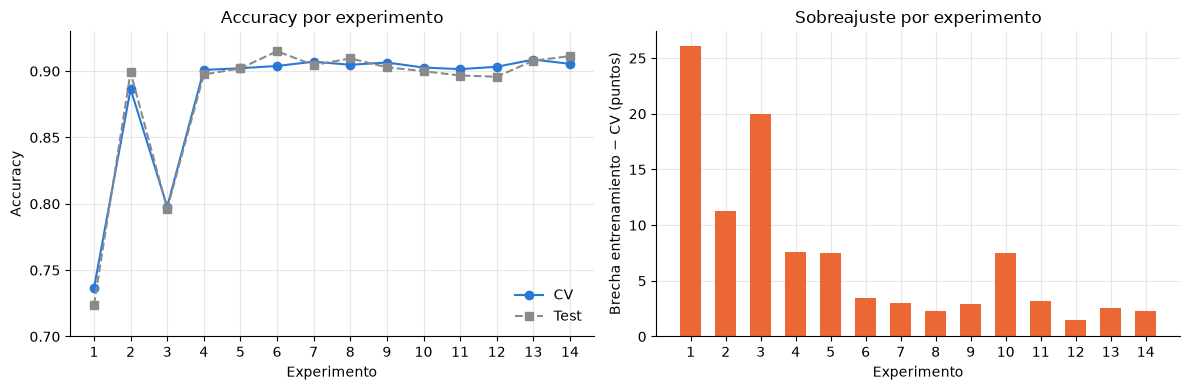

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(evolucion["experimento"], evolucion["acc_cv"], marker="o", color="#2a78d6", label="CV")
ax.plot(evolucion["experimento"], evolucion["acc_test"], marker="s", color="#8a8a8a", linestyle="--", label="Test")
ax.set_xticks(evolucion["experimento"])
ax.set_xlabel("Experimento")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.70, 0.93)
ax.set_title("Accuracy por experimento")
ax.legend(frameon=False)

ax = axes[1]
ax.bar(evolucion["experimento"], evolucion["brecha"], color="#eb6834", width=0.6)
ax.set_xticks(evolucion["experimento"])
ax.set_xlabel("Experimento")
ax.set_ylabel("Brecha entrenamiento − CV (puntos)")
ax.set_title("Sobreajuste por experimento")
plt.tight_layout()
plt.show()

**Lectura**

- **Todos los modelos usan TF-IDF** (bolsa de palabras con pesos); lo que más mejoró la accuracy no fue cambiar de
  clasificador sino **a qué parte del texto se aplica el TF-IDF**: 0,736 (un TF-IDF de la reseña completa) → 0,887
  (un TF-IDF por parte: texto completo, última oración y fragmento tras el último conector) → 0,901 (la última oración
  pasa a ser la última oración **con opinión**, elegida por el detector). Así la bolsa de palabras conserva *dónde*
  aparece cada palabra, que es lo que decide la etiqueta. Desde el experimento 6 todo queda en una **meseta** de
  0,903–0,909, con diferencias menores que la variación entre particiones.
- El **sobreajuste** bajó de 26 puntos (exp. 1) a 7,6 (exp. 4) y a 1,5–3 (exps. 11 a 14) con la accuracy constante.
- **Comparación estadística de los finalistas** (test hold-out, McNemar y bootstrap; experimentos 9, 10, 4 y 12):
  ninguna diferencia es significativa (p ≥ 0,23; todos los intervalos del 95 % incluyen el 0). En CV, el 13 supera a la
  configuración del 9 en +0,40 (p = 0,13, prueba t corregida de Nadeau y Bengio).
- Las diferencias entre envíos en el leaderboard público (±0,01) son en buena parte azar: el 60–80 % de los
  desacuerdos entre modelos cae en reseñas de etiqueta casi aleatoria. Por eso se decidió con la validación interna
  y no con el score público.

## 5. Modelo final — experimento 13

**Dos niveles (stacking):**

```
reseña → [corrector de tipeo] → detector de opinión → TF-IDF por partes → LinearSVC ──► 3 puntajes por clase  ┐
                                                    └─► modelo de polaridad (LR) por oración ──► polaridades  ├─► combinador ─► clase
                                                         estructura de la reseña (conectores, evasiva...)  ──┘   (LR + interacciones)
```

| Pieza | Qué hace | Por qué |
|---|---|---|
| Corrector de tipeo | reemplaza palabras raras por la frecuente más parecida (distancia de edición 1), con el vocabulario de entrenamiento | el 40 % del vocabulario son palabras que aparecen una vez, muchas con errores de tipeo (exp. 9) |
| Detector de opinión (`PartesE5`) | regresión logística por oración que decide si una oración expresa opinión; con él se elige la **última oración con opinión** | el veredicto está al final, pero a veces la última oración es descriptiva o evasiva (exps. 2, 4, 5) |
| TF-IDF por partes + LinearSVC | texto completo, última oración con opinión y fragmento tras el último conector, cada uno con su TF-IDF; clasificador lineal de margen máximo | da un puntaje por clase (exps. 2 y 4) |
| Modelo de polaridad | regresión logística que puntúa cada una de las últimas tres oraciones con opinión | permite comparar opiniones contrarias |
| 17 features de nivel 2 | 3 puntajes, 3 polaridades, nº de opiniones, termina en evasiva, últimas opiniones opuestas, tipo de conector de la última y la penúltima opinión | resumen denso de la reseña (exp. 6) |
| Combinador | **regresión logística con interacciones de grado 2** (`PolynomialFeatures`) | aprende reglas como "desconfiar del LinearSVC si hay muchas opiniones o la reseña termina en evasiva"; lineal y con coeficientes legibles (exps. 8 y 13) |
| Cross-fitting | las features con las que aprende el combinador se calculan con modelos de nivel 1 que **no vieron** cada reseña | sin cross-fitting, el combinador confía de más en puntajes memorizados y el modelo queda peor que uno de un nivel (exp. 7) |
| Nivel 1 sin reseñas ruidosas | el nivel 1 se entrena sin las reseñas de etiqueta casi aleatoria; el combinador sí las ve | mejor CV del proyecto; filtrar también el combinador empeora (exp. 13) |

### 5.1 Reseñas de etiqueta casi aleatoria

En el experimento 4 se encontró que las reseñas `negativo`/`positivo` cuya **última oración es una frase evasiva**
(*"ni lo mejor ni lo peor"*, *"sigo con dudas"*, *"cada quien que saque sus conclusiones"*...) tienen una etiqueta que
**ninguna parte del texto predice mejor que el azar** (0,46–0,54 con texto completo, primera oración, última opinión...).
Reseñas con la misma estructura tienen etiquetas opuestas. Un modelo no puede aprender nada de ellas; solo puede
memorizarlas.

Por eso el modelo final **no las usa para entrenar** (el nivel 1, en el caso del modelo de dos niveles). Para saber si
una reseña es de este tipo hace falta su etiqueta, así que el filtro **solo se aplica a datos de entrenamiento**,
dentro de `fit`. Al predecir (validación, test, eval) se usan **todas** las reseñas, solo con su texto.

### 5.2 Definiciones

In [25]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

In [26]:
from collections import Counter

from joblib import Parallel, delayed
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

LETRAS = "abcdefghijklmnopqrstuvwxyzñ"
PATRON_PALABRA = re.compile(r"[a-zñ]+")


def ediciones_distancia_1(palabra):
    """Todas las cadenas a distancia de edición 1: borrado, transposición, sustitución e inserción."""
    cortes = [(palabra[:i], palabra[i:]) for i in range(len(palabra) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transposiciones = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituciones = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    inserciones = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transposiciones + sustituciones + inserciones)


class CorrectorTipeo(BaseEstimator, TransformerMixin):
    """Reemplaza palabras raras por la palabra frecuente más parecida (distancia de edición 1)."""

    def __init__(self, max_rara=2, min_frecuente=15, min_largo=4):
        self.max_rara = max_rara
        self.min_frecuente = min_frecuente
        self.min_largo = min_largo

    def fit(self, X, y=None):
        self.frecuencias_ = Counter(p for texto in X for p in PATRON_PALABRA.findall(texto))
        self.frecuentes_ = {p: f for p, f in self.frecuencias_.items() if f >= self.min_frecuente}
        self.correcciones_ = {}
        for palabra, f in self.frecuencias_.items():
            if f <= self.max_rara and len(palabra) >= self.min_largo:
                candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
                if candidatas:
                    self.correcciones_[palabra] = max(sorted(candidatas), key=self.frecuentes_.get)   # empates: orden alfabético (replicable)
        return self

    def _corregir(self, palabra):
        if palabra in self.correcciones_:
            return self.correcciones_[palabra]
        if palabra not in self.frecuencias_ and len(palabra) >= self.min_largo:   # palabra nunca vista en train
            candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
            if candidatas:
                return max(sorted(candidatas), key=self.frecuentes_.get)   # empates: orden alfabético (replicable)
        return palabra

    def transform(self, X):
        return [PATRON_PALABRA.sub(lambda m: self._corregir(m.group()), texto) for texto in X]


NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}
COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]
NOMBRES_FEATURES = (["svc_negativo", "svc_neutral", "svc_positivo",
                     "pol_antepenultima", "pol_penultima", "pol_ultima",
                     "n_opiniones", "termina_evasiva", "ultimas_opuestas"]
                    + [f"ultima_{g}" for g in NOMBRES_GRUPO] + [f"penultima_{g}" for g in NOMBRES_GRUPO])


def grupo_conector(oracion):
    for g, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return g
    return "ninguno"


def es_ruidosa(textos, etiquetas):
    """Reseñas negativo/positivo que terminan en una frase evasiva (etiqueta casi aleatoria)."""
    termina_evasiva = np.array([es_evasiva(dividir_oraciones(t)[-1]) for t in textos])
    return (np.asarray(etiquetas) != "neutral") & termina_evasiva


def fit_nivel1(X, y, excluir_ruidosas=True):
    """Nivel 1: corrector, detector, TF-IDF por partes, LinearSVC y modelo de polaridad (sin reseñas ruidosas)."""
    X, y = list(X), np.asarray(y)
    limpio = ~es_ruidosa(X, y) if excluir_ruidosas else np.ones(len(y), dtype=bool)
    corrector = CorrectorTipeo().fit(X)                      # no usa etiquetas: se ajusta con todos los textos
    X = corrector.transform(X)
    X_limpio = [x for x, u in zip(X, limpio) if u]
    partes = PartesE5(quitar=True).fit(X_limpio, y[limpio])
    D = partes.transform(X_limpio)
    tfidf = ColumnTransformer([(c, tfidf_palabras(), c) for c in COLUMNAS_PARTES]).fit(D)
    base = LinearSVC(C=0.2, max_iter=5000, random_state=SEED).fit(tfidf.transform(D), y[limpio])
    usar_pol = limpio & (y != "neutral")
    ultimas = [quitar_conector(partes.opiniones(t)[-1]) for t, u in zip(X, usar_pol) if u]
    polaridad = Pipeline([
        ("tfidf", tfidf_palabras()),
        ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED)),
    ]).fit(ultimas, y[usar_pol])
    return corrector, partes, tfidf, base, polaridad


def features_nivel1(X, nivel1):
    """17 features densas por reseña: puntajes del LinearSVC + polaridades + estructura."""
    corrector, partes, tfidf, base, polaridad = nivel1
    X = corrector.transform(list(X))
    puntajes = base.decision_function(tfidf.transform(partes.transform(X)))
    estructura = []
    for texto in X:
        ops = partes.opiniones(texto)
        pols = list(polaridad.decision_function([quitar_conector(o) for o in ops[-3:]]))
        pols = [0.0] * (3 - len(pols)) + pols
        g_ult = grupo_conector(ops[-1])
        g_pen = grupo_conector(ops[-2]) if len(ops) > 1 else "ninguno"
        fila = pols + [len(ops), float(es_evasiva(dividir_oraciones(texto)[-1])), float(pols[-1] * pols[-2] < 0)]
        fila += [float(g_ult == g) for g in NOMBRES_GRUPO] + [float(g_pen == g) for g in NOMBRES_GRUPO]
        estructura.append(fila)
    return np.hstack([puntajes, np.array(estructura)])


def _parte_cf(X, y, idx_tr, idx_va):
    return idx_va, features_nivel1([X[i] for i in idx_va], fit_nivel1([X[i] for i in idx_tr], y[idx_tr]))


def features_cross_fitting(X, y, k=5, n_jobs=1):
    """Features de nivel 2 para X calculadas con modelos de nivel 1 que no vieron cada reseña."""
    X, y = list(X), np.asarray(y)
    resultados_cf = Parallel(n_jobs=n_jobs)(delayed(_parte_cf)(X, y, tr, va)
                                            for tr, va in StratifiedKFold(k, shuffle=True, random_state=SEED).split(X, y))
    F = np.zeros((len(X), len(NOMBRES_FEATURES)))
    for idx_va, f in resultados_cf:
        F[idx_va] = f
    return F


def lr_interacciones(C=0.1):
    """Combinador: regresión logística con todas las interacciones de grado 2 entre las 17 features."""
    return Pipeline([
        ("escala", StandardScaler()),
        ("interacciones", PolynomialFeatures(degree=2, include_bias=False)),
        ("escala2", StandardScaler()),
        ("clf", LogisticRegression(C=C, max_iter=5000, random_state=SEED)),
    ])


class DosNiveles(BaseEstimator, ClassifierMixin):
    """Stacking con cross-fitting; el nivel 1 se entrena sin las reseñas de etiqueta casi aleatoria."""

    def __init__(self, nivel2=None, n_jobs=5):
        self.nivel2 = nivel2
        self.n_jobs = n_jobs

    def fit(self, X, y):
        X, y = list(X), np.asarray(y)
        F = features_cross_fitting(X, y, n_jobs=self.n_jobs)    # el combinador aprende con features "honestas"
        self.nivel1_ = fit_nivel1(X, y)                          # nivel 1 con todos los datos, para predecir
        self.nivel2_ = clone(self.nivel2).fit(F, y)
        self.classes_ = self.nivel2_.classes_
        return self

    def predict(self, X):
        return self.nivel2_.predict(features_nivel1(list(X), self.nivel1_))


RUIDOSA_TRAIN = es_ruidosa(X_train, y_train)
print(f"Reseñas ruidosas en X_train: {RUIDOSA_TRAIN.sum():,} de {len(X_train):,} ({RUIDOSA_TRAIN.mean():.1%})")

Reseñas ruidosas en X_train: 1,078 de 9,600 (11.2%)


### 5.3 Ajuste del combinador con CV repetida

Calcular las features de nivel 1 es lo costoso (por el cross-fitting, cada partición entrena el nivel 1 seis
veces). Por eso se calculan una vez para cada una de las 15 particiones y se guardan; sobre ellas se elige el `C`
del combinador. Se guardan también las features de entrenamiento **dentro de muestra** (nivel 1 que vio esas reseñas)
para medir la accuracy de entrenamiento. Esta celda tarda ≈ 10 minutos.

In [27]:
import time

PARTICIONES = list(cv_repetida.split(X_train, y_train))


def _particion(idx_tr, idx_va):
    X_tr, y_tr = list(X_train.iloc[idx_tr]), y_np[idx_tr]
    nivel1 = fit_nivel1(X_tr, y_tr)
    return {"idx_tr": idx_tr, "idx_va": idx_va,
            "F_tr": features_cross_fitting(X_tr, y_tr),
            "F_tr_in": features_nivel1(X_tr, nivel1),
            "F_va": features_nivel1(list(X_train.iloc[idx_va]), nivel1)}


inicio = time.time()
CACHE = Parallel(n_jobs=-1)(delayed(_particion)(tr, va) for tr, va in PARTICIONES)
print(f"Features de nivel 2 para {len(CACHE)} particiones en {(time.time() - inicio) / 60:.1f} min")


def evaluar_combinador(fabrica):
    filas = []
    for c in CACHE:
        m = fabrica().fit(c["F_tr"], y_np[c["idx_tr"]])
        p_tr, p_va = m.predict(c["F_tr_in"]), m.predict(c["F_va"])
        filas.append({"acc_train": (p_tr == y_np[c["idx_tr"]]).mean(), "acc_cv": (p_va == y_np[c["idx_va"]]).mean(),
                      "cv_ruidosas": (p_va == y_np[c["idx_va"]])[RUIDOSA_TRAIN[c["idx_va"]]].mean(),
                      "cv_resto": (p_va == y_np[c["idx_va"]])[~RUIDOSA_TRAIN[c["idx_va"]]].mean()})
    return pd.DataFrame(filas)


EVAL = {C: evaluar_combinador(lambda C=C: lr_interacciones(C)) for C in [0.01, 0.03, 0.1]}
tabla = pd.DataFrame({C: {"acc_train": r["acc_train"].mean(), "acc_cv": r["acc_cv"].mean(),
                          "std_cv": r["acc_cv"].std(ddof=0), "brecha (puntos)": 100 * (r["acc_train"] - r["acc_cv"]).mean(),
                          "cv | ruidosas": r["cv_ruidosas"].mean(), "cv | resto": r["cv_resto"].mean()}
                      for C, r in EVAL.items()}).T
tabla.index.name = "C del combinador"
C_FINAL = tabla["acc_cv"].idxmax()
print(f"C elegido: {C_FINAL} | CV = {tabla.loc[C_FINAL, 'acc_cv']:.4f}")
tabla.round(4)

Features de nivel 2 para 15 particiones en 2.8 min


C elegido: 0.1 | CV = 0.9088


,acc_train,acc_cv,std_cv,brecha (puntos),cv | ruidosas,cv | resto
C del combinador,,,,,,
0.01,0.9300,0.9081,0.0072,2.1910,0.5117,0.9581
0.03,0.9325,0.9085,0.0073,2.4019,0.5138,0.9583
0.10,0.9344,0.9088,0.0060,2.5608,0.5159,0.9584


**Lectura:** la accuracy de CV es estable frente a `C` (meseta); la CV elige el valor final. En las
reseñas ruidosas el modelo acierta ≈ 50 % (azar, como cualquier modelo) y en el resto ≈ 95 %.

### 5.4 Evaluación en test

Test -> accuracy: 0.9079 | F1 macro: 0.9125

              precision    recall  f1-score   support

    negativo      0.863     0.880     0.871       843
     neutral      0.999     0.997     0.998       715
    positivo      0.877     0.860     0.868       842

    accuracy                          0.908      2400
   macro avg      0.913     0.912     0.912      2400
weighted avg      0.908     0.908     0.908      2400



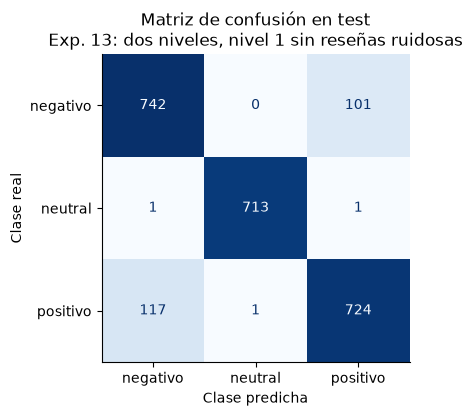

Reseñas ruidosas del test (285): 0.498
Resto del test (2115): 0.963


In [28]:
modelo_final = DosNiveles(nivel2=lr_interacciones(C_FINAL)).fit(X_train, y_train)
pred_test = evaluar_en_test(modelo_final, "Exp. 13: dos niveles, nivel 1 sin reseñas ruidosas")
ruidosa_test = es_ruidosa(X_test, y_test)
y_t = y_test.to_numpy()
print(f"Reseñas ruidosas del test ({ruidosa_test.sum()}): {(pred_test[ruidosa_test] == y_t[ruidosa_test]).mean():.3f}")
print(f"Resto del test ({(~ruidosa_test).sum()}): {(pred_test[~ruidosa_test] == y_t[~ruidosa_test]).mean():.3f}")

### 5.5 ¿Qué aprendió el combinador?

Coeficientes de la regresión logística de nivel 2 (features estandarizadas, así que son comparables). "a b" es el
producto de dos features (interacción).

In [29]:
comb = modelo_final.nivel2_
nombres = comb.named_steps["interacciones"].get_feature_names_out(NOMBRES_FEATURES)
coef = pd.DataFrame(comb.named_steps["clf"].coef_.T, index=nombres, columns=comb.named_steps["clf"].classes_)
pd.DataFrame({clase: [f"{n} ({coef.loc[n, clase]:+.2f})" for n in coef[clase].abs().sort_values(ascending=False).index[:12]]
              for clase in ["negativo", "positivo"]})

,negativo,positivo
0,svc_negativo (+1.23),svc_positivo (+1.12)
1,svc_neutral (-0.56),svc_negativo (-0.69)
2,svc_positivo (-0.54),svc_positivo n_opiniones (-0.53)
3,svc_neutral svc_positivo (+0.52),svc_neutral ultimas_opuestas (+0.49)
4,svc_positivo pol_ultima (+0.44),svc_neutral pol_penultima (+0.48)
5,pol_ultima (-0.44),pol_ultima (+0.40)
6,svc_neutral n_opiniones (+0.40),svc_negativo pol_ultima (-0.39)
7,svc_negativo n_opiniones (-0.40),svc_negativo svc_neutral (+0.35)
8,svc_neutral pol_penultima (-0.38),svc_neutral (-0.30)
9,svc_positivo pol_penultima (-0.34),svc_neutral svc_positivo (-0.30)


**Lectura:** la base de la decisión son los puntajes del LinearSVC (`svc_negativo`, `svc_positivo`), y la polaridad
de la última opinión (`pol_ultima`) aporta información propia. Las interacciones de mayor peso indican **cuándo
desconfiar** del LinearSVC: `svc_positivo × n_opiniones` es negativa para `positivo` (con muchas opiniones en la reseña,
un puntaje positivo alto vale menos) y `svc_neutral × ultimas_opuestas` es positiva (si las dos últimas opiniones se
contradicen, el modelo se apoya en otras señales). Las interacciones con `pol_ultima` y `pol_penultima` ajustan cuánto
pesa la polaridad de las últimas opiniones según lo que diga el LinearSVC. Son el tipo de reglas que se habían
encontrado a mano en el análisis de errores (muchas opiniones, opiniones contrarias), aprendidas aquí de los datos.

## 6. Sobreajuste y robustez

### 6.1 ¿De dónde viene la brecha?

Con las 15 particiones de la sección 5.3 y el `C` elegido: accuracy de entrenamiento (dentro de muestra) y de
validación, separando las reseñas ruidosas del resto.

In [30]:
r = EVAL[C_FINAL]
filas = []
for c in CACHE:
    m = lr_interacciones(C_FINAL).fit(c["F_tr"], y_np[c["idx_tr"]])
    for parte, idx, F in [("entrenamiento", c["idx_tr"], c["F_tr_in"]), ("validación", c["idx_va"], c["F_va"])]:
        a, rr = m.predict(F) == y_np[idx], RUIDOSA_TRAIN[idx]
        filas.append({"parte": parte, "total": a.mean(), "reseñas ruidosas": a[rr].mean(), "resto": a[~rr].mean()})
diag = pd.DataFrame(filas).groupby("parte").mean().loc[["entrenamiento", "validación"]]
diag.loc["brecha"] = diag.loc["entrenamiento"] - diag.loc["validación"]
diag.round(4)

,total,reseñas ruidosas,resto
parte,,,
entrenamiento,0.9344,0.5489,0.9832
validación,0.9088,0.5159,0.9584
brecha,0.0256,0.0331,0.0247


**Lectura:** la brecha total es de ≈ 2–3 puntos (exp. 4: 7,6). Una parte es memorización de las reseñas
ruidosas por el combinador (que sí las ve), que no sirve en datos nuevos; en las reseñas predecibles la brecha es
moderada y la accuracy de validación ≈ 95 %. En el experimento 13 la curva de aprendizaje mostró además que la
validación sigue subiendo con más datos y la brecha se cierra: el modelo está limitado por los datos, no por exceso
de capacidad.

### 6.2 Robustez ante cambios en la posición del veredicto

El modelo aprovecha que en estos datos el veredicto está al final de la reseña (lo indica el enunciado: recencia y
conectores). Para medir cuánto depende de eso, se altera el test: oraciones desordenadas al azar y última oración
movida al inicio.

In [31]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {"Original": X_test, "Oraciones desordenadas": desordenar_oraciones(X_test),
              "Última oración al inicio": ultima_al_inicio(X_test)}
pd.DataFrame({"accuracy": {e: accuracy_score(y_test, modelo_final.predict(X_e)) for e, X_e in ESCENARIOS.items()}}).round(4)

,accuracy
Original,0.9079
Oraciones desordenadas,0.7762
Última oración al inicio,0.6546


**Lectura:** el modelo pierde accuracy cuando el veredicto deja de estar al final. Es una limitación de
cualquier modelo de bolsa de palabras sobre estos datos (la etiqueta depende del orden, experimento 3): funciona
porque `eval.csv` tiene la misma estructura que train, pero no debería usarse con reseñas de otra fuente sin
validarlo. Los modelos secuenciales de la Parte 2 deberían aprender el orden de forma general.

## 7. Envío y modelo guardado

El modelo final se reentrena con las **12.000 reseñas** de `train.csv`. Para que el archivo guardado reciba **texto
crudo**, la normalización (`normalizar_texto`) va como primer paso del pipeline. Después se verifica la
replicabilidad: se carga el `.joblib` desde disco, se predice `eval.csv` y se compara con el envío que se subió a
Kaggle (`envios/submission_13.csv`).

**Para cargar el modelo** hay que ejecutar antes las celdas de definiciones de este notebook (`joblib` guarda las
funciones y clases propias por referencia).

In [32]:
import sklearn


def normalizar_lista(textos):
    return [normalizar_texto(t) for t in textos]


modelo_entrega = Pipeline([
    ("normalizar", FunctionTransformer(normalizar_lista)),
    ("modelo", clone(modelo_final)),
]).fit(train["text"], train["label"])

Path("entrega").mkdir(exist_ok=True)
RUTA_MODELO = "entrega/modelo_final_exp13.joblib"
RUTA_ENVIO = "entrega/submission_final_exp13.csv"
joblib.dump(modelo_entrega, RUTA_MODELO)

envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo_entrega.predict(eval_df["text"])})
assert list(envio.columns) == ["id", "answer"] and len(envio) == 3000
assert set(envio["id"]) == set(sample_submission["id"]) and set(envio["answer"]) <= set(CLASES)
envio.to_csv(RUTA_ENVIO, index=False)
print(f"Modelo guardado en {RUTA_MODELO} y envío en {RUTA_ENVIO} (scikit-learn {sklearn.__version__})")
print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())

Modelo guardado en entrega/modelo_final_exp13.joblib y envío en entrega/submission_final_exp13.csv (scikit-learn 1.9.0)
answer
negativo    36.0
neutral     27.6
positivo    36.4


In [33]:
# Verificación de replicabilidad: modelo cargado desde disco frente al envío subido a Kaggle
cargado = joblib.load(RUTA_MODELO)
pred_cargado = cargado.predict(eval_df["text"])
subido = pd.read_csv("envios/submission_13.csv").set_index("id").loc[eval_df["id"], "answer"].to_numpy()
print(f"Predicciones del modelo cargado iguales al envío subido a Kaggle: {(pred_cargado == subido).mean():.2%}")
print(f"Predicciones del modelo cargado iguales al envío generado aquí:   {(pred_cargado == envio['answer'].to_numpy()).mean():.2%}")

Predicciones del modelo cargado iguales al envío subido a Kaggle: 99.93%
Predicciones del modelo cargado iguales al envío generado aquí:   100.00%


**Lectura:** el modelo guardado reproduce exactamente su propio envío (100 %) y coincide con el envío del
experimento 13 subido a Kaggle en 2.998 de 3.000 reseñas (las de `id` 89 y 811 cambian entre `negativo` y `positivo`).

La diferencia viene de un detalle de replicabilidad que se encontró al preparar esta entrega: el corrector de tipeo
elegía la corrección con `max` sobre un conjunto (`set`) de candidatas, y cuando dos candidatas tenían la misma
frecuencia el desempate dependía del orden de hash de Python, que cambia en cada sesión. En el modelo final solo hay
un empate (`vivi`), pero en las particiones del cross-fitting aparecen otros, y eso cambia levemente el combinador.
Aquí el desempate es **alfabético** (`max(sorted(candidatas), ...)`): con dos semillas de hash distintas
(`PYTHONHASHSEED`) el notebook produjo las mismas 3.000 predicciones. El test (0,9079) y la CV son iguales a los del
experimento 13.

## 8. Conclusiones

- **Modelo final (experimento 13):** modelo de dos niveles con el nivel 1 entrenado sin las reseñas de etiqueta
  casi aleatoria y un combinador lineal con interacciones. Es el **mejor modelo según la validación** (CV 0,909 con 15
  particiones), el más robusto de los modelos de dos niveles y su combinador se puede leer como reglas.
- **Lo que más mejoró el modelo fue a qué texto se aplica el TF-IDF**, no el clasificador: separar la reseña en partes
  (el veredicto está al final), elegir la última oración con opinión y darle a cada parte su propio TF-IDF. De 0,736
  (un TF-IDF de la reseña completa) a ≈ 0,90, siempre con TF-IDF y clasificadores lineales.
- **≈ 11 % de las reseñas tiene una etiqueta prácticamente aleatoria** (reseñas `negativo`/`positivo` que terminan en
  una frase evasiva). Ningún modelo las acierta más que el azar; fijan un techo de accuracy ≈ 0,94 y hacen que las
  diferencias de ±0,01 entre envíos en el leaderboard sean en buena parte ruido.
- **El sobreajuste se controló sin perder accuracy:** selección de features (chi²) y no entrenar con las reseñas de
  etiqueta aleatoria redujeron la brecha de 7,6 a 1,5–2,6 puntos. La curva de aprendizaje muestra que el límite es la
  cantidad de datos, no un exceso de capacidad.
- **Decisiones con validación, no con el leaderboard público:** el modelo con mejor score público (experimento 9)
  bajó en el ranking privado; los finalistas no tienen diferencias estadísticamente significativas (McNemar y prueba t
  corregida), y se eligió por validación, simplicidad y robustez.

**Límites:**
- El modelo depende de que el veredicto esté al final de la reseña (sección 6.2); con otra estructura de texto pierde
  accuracy.
- La lista de frases evasivas y de conectores se construyó a mano con el análisis de errores de `X_train`.
- Con representaciones de bolsa de palabras no se puede aprovechar el orden de forma general: es el punto de partida
  de la Parte 2 (modelos secuenciales).

## 9. Uso de IA generativa

*(Borrador para que el grupo lo revise y complete.)*

En el desarrollo de esta parte del proyecto se usó un asistente de IA generativa (Claude, de Anthropic) como apoyo
para:
- discutir y diseñar los experimentos y la estrategia de validación;
- escribir y depurar código (pipelines de scikit-learn, funciones auxiliares, gráficos);
- analizar resultados y redactar la documentación de los notebooks.

Las decisiones de modelado, la revisión del código y de los resultados, las preguntas de fondo (por ejemplo, sobre
sobreajuste, explicabilidad y reglas del curso) y la elección del modelo final fueron del grupo. Todos los resultados
reportados se obtuvieron ejecutando el código de los notebooks del repositorio. Ningún modelo de lenguaje se usó como
parte del modelo de clasificación ni para etiquetar datos.